In [1]:
import mmbra
import mmbracategories

import torch
import os
import scipy.io as sio

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.feature_selection import mutual_info_classif

import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
#Code from Google Collab



# load data
data_dir_root = os.path.join('./data', 'ThingsEEG-Text')
sbj = 'sub-10'
image_model = 'pytorch/cornet_s'
text_model = 'CLIPText'
roi = '17channels'

# getting directory and joining that
brain_dir = os.path.join(data_dir_root, 'brain_feature', roi, sbj)
image_dir_seen = os.path.join(data_dir_root, 'visual_feature/ThingsTrain', image_model, sbj)
image_dir_unseen = os.path.join(data_dir_root, 'visual_feature/ThingsTest', image_model, sbj)
text_dir_seen = os.path.join(data_dir_root, 'textual_feature/ThingsTrain/text', text_model, sbj)
text_dir_unseen = os.path.join(data_dir_root, 'textual_feature/ThingsTest/text', text_model, sbj)

# Data Loading

# set up directory by constructing data paths to the data sets
# organizes these paths based on the subject identifier, data type (training or testing), and the model used (e.g., image and text models).
# datasets are loaded from .mat files using the scipy.io.loadmat() function.
# function reads the data into numpy arrays, facilitating data manipulation.


# Data Preprocessing

# For the brain data, specific time intervals are extracted and the data is reshaped to a two-dimensional format to simplify analysis
# Image and text data are scaled to enhance numerical stability during model training
# Dimensionality reduction is applied to the image data to limit the number of features, making the dataset more manageable and reducing computational complexity

# Conversion to PyTorch Tensors

# The numpy arrays for each dataset (brain, image, text, and labels) are converted into PyTorch tensors. 
# This conversion is crucial for efficient data handling in neural network training, as tensors are optimized for operations on GPU.

brain_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['data'].astype('double') * 2.0
brain_seen = brain_seen[:,:,27:60] # 70ms-400ms
brain_seen = np.reshape(brain_seen, (brain_seen.shape[0], -1))
image_seen = sio.loadmat(os.path.join(image_dir_seen, 'feat_pca_train.mat'))['data'].astype('double')*50.0
text_seen = sio.loadmat(os.path.join(text_dir_seen, 'text_feat_train.mat'))['data'].astype('double')*2.0
label_seen = sio.loadmat(os.path.join(brain_dir, 'eeg_train_data_within.mat'))['class_idx'].T.astype('int')
image_seen = image_seen[:,0:100]

brain_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['data'].astype('double')*2.0
brain_unseen = brain_unseen[:, :, 27:60]
brain_unseen = np.reshape(brain_unseen, (brain_unseen.shape[0], -1))
image_unseen = sio.loadmat(os.path.join(image_dir_unseen, 'feat_pca_test.mat'))['data'].astype('double')*50.0
text_unseen = sio.loadmat(os.path.join(text_dir_unseen, 'text_feat_test.mat'))['data'].astype('double')*2.0
label_unseen = sio.loadmat(os.path.join(brain_dir, 'eeg_test_data.mat'))['class_idx'].T.astype('int')
image_unseen = image_unseen[:, 0:100]

brain_seen = torch.from_numpy(brain_seen)
brain_unseen = torch.from_numpy(brain_unseen)
image_seen = torch.from_numpy(image_seen)
image_unseen = torch.from_numpy(image_unseen)
text_seen = torch.from_numpy(text_seen)
text_unseen = torch.from_numpy(text_unseen)
label_seen = torch.from_numpy(label_seen)
label_unseen = torch.from_numpy(label_unseen)

# Summary 

# The code prints the shape of each dataset, providing an overview of the number of samples and features for both training and testing sets. 
# This summary helps confirm that the data is correctly formatted and that the expected number of features is present. 
# This process of data loading, preprocessing, and conversion into PyTorch tensors ensures that the brain, image, and text datasets are ready for further analysis or machine learning tasks.

print('seen_brain_samples=', brain_seen.shape[0], ', seen_brain_features=', brain_seen.shape[1])
print('seen_image_samples=', image_seen.shape[0], ', seen_image_features=', image_seen.shape[1])
print('seen_text_samples=', text_seen.shape[0], ', seen_text_features=', text_seen.shape[1])
print('seen_label=', label_seen.shape)
print('unseen_brain_samples=', brain_unseen.shape[0], ', unseen_brain_features=', brain_unseen.shape[1])
print('unseen_image_samples=', image_unseen.shape[0], ', unseen_image_features=', image_unseen.shape[1])
print('unseen_text_samples=', text_unseen.shape[0], ', unseen_text_features=', text_unseen.shape[1])
print('unseen_label=', label_unseen.shape)

seen_brain_samples= 16540 , seen_brain_features= 561
seen_image_samples= 16540 , seen_image_features= 100
seen_text_samples= 16540 , seen_text_features= 512
seen_label= torch.Size([16540, 1])
unseen_brain_samples= 16000 , unseen_brain_features= 561
unseen_image_samples= 16000 , unseen_image_features= 100
unseen_text_samples= 16000 , unseen_text_features= 512
unseen_label= torch.Size([16000, 1])


In [3]:
#SO DATA IS IN PYTORCH TENSORS RIGHT NOW

In [4]:
label_seen

tensor([[   1],
        [   1],
        [   1],
        ...,
        [1654],
        [1654],
        [1654]])

In [5]:
mmbracategories.print_seen_categories()

00001_aardvark
00002_abacus
00003_accordion
00004_acorn
00005_air_conditioner
00006_air_mattress
00007_air_pump
00008_airbag
00009_airboat
00010_airplane
00011_album
00012_alligator
00013_almond
00014_aloe
00015_alpaca
00016_altar
00017_aluminum_foil
00018_amber
00019_ambulance
00020_amplifier
00021_anchor
00022_ankle
00023_anklet
00024_ant
00025_anteater
00026_antenna
00027_anvil
00028_appetizer
00029_apple
00030_apple_tree
00031_applesauce
00032_apron
00033_aquarium
00034_arch
00035_arm
00036_armor
00037_arrow
00038_artichoke
00039_arugula
00040_ashtray
00041_asparagus
00042_avocado
00043_awning
00044_axe
00045_baby
00046_backdrop
00047_backgammon
00048_backpack
00049_bacon
00050_badge
00051_badger
00052_bag
00053_bagel
00054_bagpipe
00055_baklava
00056_ball
00057_balloon
00058_ballot_box
00059_bamboo
00060_banana_peel
00061_banana_split
00062_bandage
00063_bandanna
00064_banjo
00065_bank
00066_banner
00067_barbed_wire
00068_barbell
00069_barcode
00070_bark
00071_barnacle
00072_barre

In [6]:
mmbracategories.print_unseen_categories()

00001_aircraft_carrier
00002_antelope
00003_backscratcher
00004_balance_beam
00005_banana
00006_baseball_bat
00007_basil
00008_basketball
00009_bassoon
00010_baton4
00011_batter
00012_beaver
00013_bench
00014_bike
00015_birthday_cake
00016_blowtorch
00017_boat
00018_bok_choy
00019_bonnet
00020_bottle_opener
00021_brace
00022_bread
00023_breadbox
00024_bug
00025_buggy
00026_bullet
00027_bun
00028_bush
00029_calamari
00030_candlestick
00031_cart
00032_cashew
00033_cat
00034_caterpillar
00035_cd_player
00036_chain
00037_chaps
00038_cheese
00039_cheetah
00040_chest2
00041_chime
00042_chopsticks
00043_cleat
00044_cleaver
00045_coat
00046_cobra
00047_coconut
00048_coffee_bean
00049_coffeemaker
00050_cookie
00051_cordon_bleu
00052_coverall
00053_crab
00054_creme_brulee
00055_crepe
00056_crib
00057_croissant
00058_crow
00059_cruise_ship
00060_crumb
00061_cupcake
00062_dagger
00063_dalmatian
00064_dessert
00065_dragonfly
00066_dreidel
00067_drum
00068_duffel_bag
00069_eagle
00070_eel
00071_egg


In [7]:


# STEP 1) DATASET EXPOLORATION



In [8]:
# Summary Statistics

#Convert data into Pandas Dataframe for easier exploration and anaylsis.
mmbra.data_analysis_example(brain_seen, image_seen, text_seen)


Brain data summary statistics:
                0             1             2             3             4    \
count  16540.000000  16540.000000  16540.000000  16540.000000  16540.000000   
mean       0.076787      0.070698      0.028373     -0.044438     -0.067034   
std        0.583893      0.592233      0.610593      0.630831      0.641200   
min       -2.762807     -2.598095     -2.349412     -2.818633     -3.008686   
25%       -0.309925     -0.320417     -0.378459     -0.459167     -0.493376   
50%        0.072401      0.068746      0.033988     -0.046756     -0.061193   
75%        0.464845      0.459148      0.433262      0.374403      0.357285   
max        2.293334      2.570706      2.949977      2.507507      2.499492   

                5             6             7             8             9    \
count  16540.000000  16540.000000  16540.000000  16540.000000  16540.000000   
mean      -0.127158     -0.140791     -0.122330     -0.069163     -0.012199   
std        0.646158 

In [9]:
#FINDING VARIANCE (THE SPREAD OF DATA POINTS)

#BRAIN_SEEN
brain_seen_df = pd.DataFrame(brain_seen.numpy())  # Convert PyTorch tensor to DataFrame if needed

# Calculate variance for each feature (column-wise)
brain_variance = brain_seen_df.var()

# Display variance for the first 10 features
print("Feature-wise Variance:")

print(brain_variance)

print("max variance:", brain_variance.max())
print("min variance:", brain_variance.min())

Feature-wise Variance:
0      0.340931
1      0.350739
2      0.372823
3      0.397948
4      0.411137
         ...   
556    0.545683
557    0.547624
558    0.544932
559    0.553786
560    0.556584
Length: 561, dtype: float64
max variance: 2.628355568267755
min variance: 0.32284013134901807


In [10]:
brain_seen_df.dtypes

0      float64
1      float64
2      float64
3      float64
4      float64
        ...   
556    float64
557    float64
558    float64
559    float64
560    float64
Length: 561, dtype: object

In [11]:
brain_seen_df.head()

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.181086,0.383238,0.148572,0.362642,0.380157,-0.132330,-0.835796,-0.211023,-0.674189,-0.893508,...,0.427987,0.610989,0.616923,0.591801,0.490052,0.644682,0.792858,1.281184,0.697889,1.010584
1,-0.269994,-0.161154,-0.173305,0.246614,0.114574,0.064350,-0.636511,-0.740275,-0.681264,-0.396427,...,-0.110054,0.080109,0.027442,-0.055867,-0.374436,-0.385487,-0.586066,-0.080922,0.219903,0.374939
2,-1.101100,-0.196966,0.507806,0.552215,0.416258,-1.073705,-1.887706,-1.590339,-1.346330,-1.468380,...,-0.229028,-0.281819,-0.998308,-0.836045,-0.829408,-0.497759,-0.920635,-0.910904,-1.170002,-0.693476
3,0.329524,0.292627,-0.183675,0.167948,-0.144916,0.333150,0.744820,1.047985,0.677371,0.637663,...,-0.567553,-0.319176,-0.300166,-0.702255,-0.386382,-0.746872,-1.101821,-0.679398,0.076642,0.645036
4,1.238872,1.528632,1.182186,1.217510,0.921484,0.748299,0.282835,0.043261,-0.175415,0.023306,...,0.411135,0.198496,0.397676,-0.039232,-0.207496,-0.090975,0.121724,0.022155,-0.288865,-0.056377


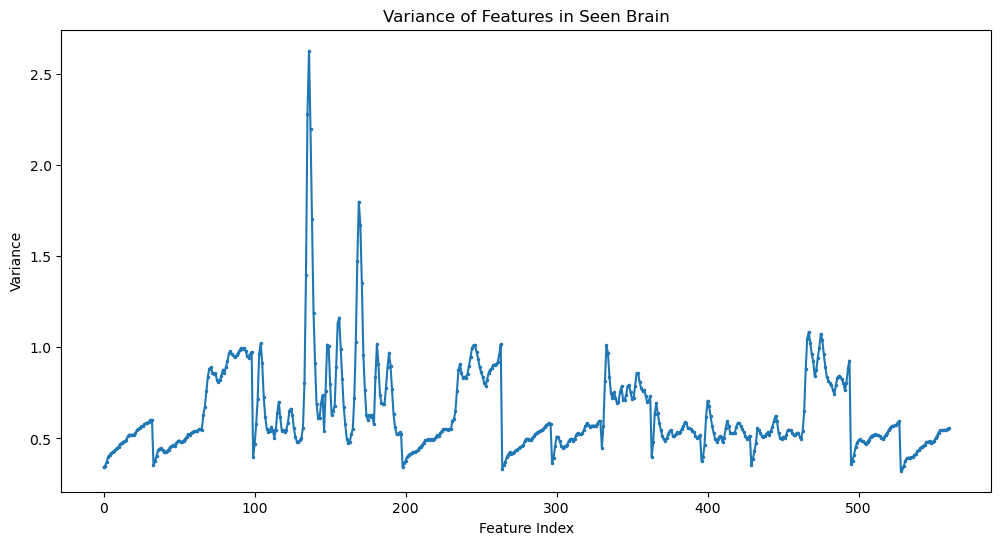

In [12]:
# Plot feature variances
plt.figure(figsize=(12, 6))
brain_variance.plot(kind='line', marker='.', linestyle='-', markersize=3)
plt.xlabel("Feature Index")
plt.ylabel("Variance")
plt.title("Variance of Features in Seen Brain")
plt.show()

In [13]:
brain_seen_df

,0,1,2,3,4,5,6,7,8,9,...,551,552,553,554,555,556,557,558,559,560
0,0.181086,0.383238,0.148572,0.362642,0.380157,-0.132330,-0.835796,-0.211023,-0.674189,-0.893508,...,0.427987,0.610989,0.616923,0.591801,0.490052,0.644682,0.792858,1.281184,0.697889,1.010584
1,-0.269994,-0.161154,-0.173305,0.246614,0.114574,0.064350,-0.636511,-0.740275,-0.681264,-0.396427,...,-0.110054,0.080109,0.027442,-0.055867,-0.374436,-0.385487,-0.586066,-0.080922,0.219903,0.374939
2,-1.101100,-0.196966,0.507806,0.552215,0.416258,-1.073705,-1.887706,-1.590339,-1.346330,-1.468380,...,-0.229028,-0.281819,-0.998308,-0.836045,-0.829408,-0.497759,-0.920635,-0.910904,-1.170002,-0.693476
3,0.329524,0.292627,-0.183675,0.167948,-0.144916,0.333150,0.744820,1.047985,0.677371,0.637663,...,-0.567553,-0.319176,-0.300166,-0.702255,-0.386382,-0.746872,-1.101821,-0.679398,0.076642,0.645036
4,1.238872,1.528632,1.182186,1.217510,0.921484,0.748299,0.282835,0.043261,-0.175415,0.023306,...,0.411135,0.198496,0.397676,-0.039232,-0.207496,-0.090975,0.121724,0.022155,-0.288865,-0.056377
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16535,-1.604236,-1.640201,-1.086691,-1.027874,-0.915829,-0.097174,-0.435947,-0.056560,-0.038493,-0.209834,...,-0.024025,0.880912,0.842154,1.271662,0.895667,0.500352,-0.247941,-0.158689,0.626525,0.634617
16536,0.322145,0.605149,0.564480,-0.023314,-0.336303,-0.481493,0.068125,0.504193,0.542020,0.077422,...,-0.094923,-0.399100,-0.730020,-0.524488,-0.073217,-0.620877,-0.849844,-0.286727,0.095967,0.037526
16537,-0.175904,-0.306548,-0.755333,-0.949823,-0.780171,-0.235978,-0.450251,0.071519,-0.244009,-0.311065,...,0.210547,-0.159578,-0.410633,-0.430555,-0.203233,-0.326210,-0.271333,-0.020330,-0.536369,-0.575081
16538,0.005099,-0.037819,-0.178253,0.436937,1.088537,1.056409,0.699936,0.769469,0.524528,0.439184,...,0.805248,0.828066,0.268703,0.420957,0.383024,0.637339,0.502506,-0.119756,-0.187219,0.156173


In [14]:
label_seen

tensor([[   1],
        [   1],
        [   1],
        ...,
        [1654],
        [1654],
        [1654]])

In [15]:
means = brain_seen_df.mean()
stds = brain_seen_df.std()

print("Feature-wise Means (first 10):", means.head(10))
print("Feature-wise Std Devs (first 10):", stds.head(10))

Feature-wise Means (first 10): 0    0.076787
1    0.070698
2    0.028373
3   -0.044438
4   -0.067034
5   -0.127158
6   -0.140791
7   -0.122330
8   -0.069163
9   -0.012199
dtype: float64
Feature-wise Std Devs (first 10): 0    0.583893
1    0.592233
2    0.610593
3    0.630831
4    0.641200
5    0.646158
6    0.652630
7    0.658116
8    0.664252
9    0.668929
dtype: float64


In [16]:
#DATA COMPRESSION FOR BRAIN!

In [17]:
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis

# Initialize LDA
lda = LinearDiscriminantAnalysis()
reduced_data = lda.fit_transform(brain_seen_df, label_seen)

/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [18]:
# # Get the LDA components
# lda_components = lda.scalings_

# # Create a DataFrame to map LDA components to original feature names
# lda_df = pd.DataFrame(lda_components, index=X.columns, columns=[f'LDA{i+1}' for i in range(lda_components.shape[1])])

# # Map LDA components to original feature names
# # For each LDA component, find the top contributing original feature
# top_features_per_component = {}
# for i in range(lda_components.shape[1]):
#     top_feature = lda_df.nlargest(1, f'LDA{i+1}').index[0]
#     top_features_per_component[f'LDA{i+1}'] = top_feature

# # Replace LDA component names in `mi_df` with the top contributing original feature names
# mi_df['Feature'] = mi_df['Feature'].replace(top_features_per_component)

# # Sort the DataFrame by 'MI Score' in descending order and select the top 20 features
# mi_df = mi_df.sort_values(by='MI Score', ascending=False).head(20)

# # Define quartile colors
# colors = ['#36669c', '#41a0ae', '#3ec995', '#77f07f']  # Colors for each quartile

# # Determine quartile ranges for the top 20 features
# num_features = len(mi_df['Feature'])
# quartile_size = num_features // 4  # Number of features per quartile

# # Assign colors to bars based on their quartile
# bar_colors = []
# for i in range(num_features):
#     if i < quartile_size:
#         bar_colors.append(colors[0])  # First quartile
#     elif i < quartile_size * 2:
#         bar_colors.append(colors[1])  # Second quartile
#     elif i < quartile_size * 3:
#         bar_colors.append(colors[2])  # Third quartile
#     else:
#         bar_colors.append(colors[3])  # Fourth quartile

# # Plot the data
# plt.figure(figsize=(18, 10))
# plt.bar(mi_df['Feature'], mi_df['MI Score'], color=bar_colors, alpha=0.8)

# # Add axis labels and title
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.title('Top 20 Mutual Information Scores for Original Features', fontsize=14)
# plt.xlabel('Original Features', fontsize=12)
# plt.ylabel('Mutual Information Score', fontsize=12)

# # Add a legend to explain quartiles
# legend_labels = ['First Quartile (0-25%)', 'Second Quartile (26-50%)', 'Third Quartile (51-75%)', 'Fourth Quartile (76-100%)']
# legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(4)]
# plt.legend(handles=legend_patches, title="X-axis Quartiles", fontsize=10)

# # Improve layout
# plt.tight_layout()
# plt.show()

In [19]:
# Convert PyTorch tensor to NumPy if needed
seen_label_np = label_seen.numpy().ravel()  # Replace with your actual label variable

In [20]:
#MAKING MIC to find top 20 columns

# Compute mutual information between LDA components and labels
mi_scores = mutual_info_classif(reduced_data, seen_label_np)

# Create a DataFrame for easier interpretation
mi_df = pd.DataFrame({'Feature': [f'LD{i+1}' for i in range(reduced_data.shape[1])], 'MI Score': mi_scores})

# Sort features by MI score
mi_df = mi_df.sort_values(by='MI Score', ascending=False)
print(mi_df)

    Feature  MI Score
0       LD1  0.585118
1       LD2  0.526936
2       LD3  0.480400
3       LD4  0.450314
4       LD5  0.369864
..      ...       ...
378   LD379  0.000000
379   LD380  0.000000
380   LD381  0.000000
381   LD382  0.000000
560   LD561  0.000000

[561 rows x 2 columns]


In [21]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# # Define quartile colors
# colors = ['#36669c', '#41a0ae', '#3ec995', '#77f07f']  # Colors for each quartile

# # Determine quartile ranges
# num_features = len(mi_df['Feature'])
# quartile_size = num_features // 4  # Number of features per quartile

# # Assign colors to bars based on their quartile
# bar_colors = []
# for i in range(num_features):
#     if i < quartile_size:
#         bar_colors.append(colors[0])  # First quartile
#     elif i < quartile_size * 2:
#         bar_colors.append(colors[1])  # Second quartile
#     elif i < quartile_size * 3:
#         bar_colors.append(colors[2])  # Third quartile
#     else:
#         bar_colors.append(colors[3])  # Fourth quartile

# # Plot the data
# plt.figure(figsize=(18, 10))
# plt.bar(mi_df['Feature'], mi_df['MI Score'], color=bar_colors, alpha=0.8)

# # Add axis labels and title
# plt.xticks(rotation=45, ha='right', fontsize=10)
# plt.title('Mutual Information Scores for LDA Components', fontsize=14)
# plt.xlabel('LDA Components', fontsize=12)
# plt.ylabel('Mutual Information Score', fontsize=12)

# # Add a legend to explain quartiles
# legend_labels = ['First Quartile (0-25%)', 'Second Quartile (26-50%)', 'Third Quartile (51-75%)', 'Fourth Quartile (76-100%)']
# legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(4)]
# plt.legend(handles=legend_patches, title="X-axis Quartiles", fontsize=10)

# # Improve layout
# plt.tight_layout()
# plt.show()

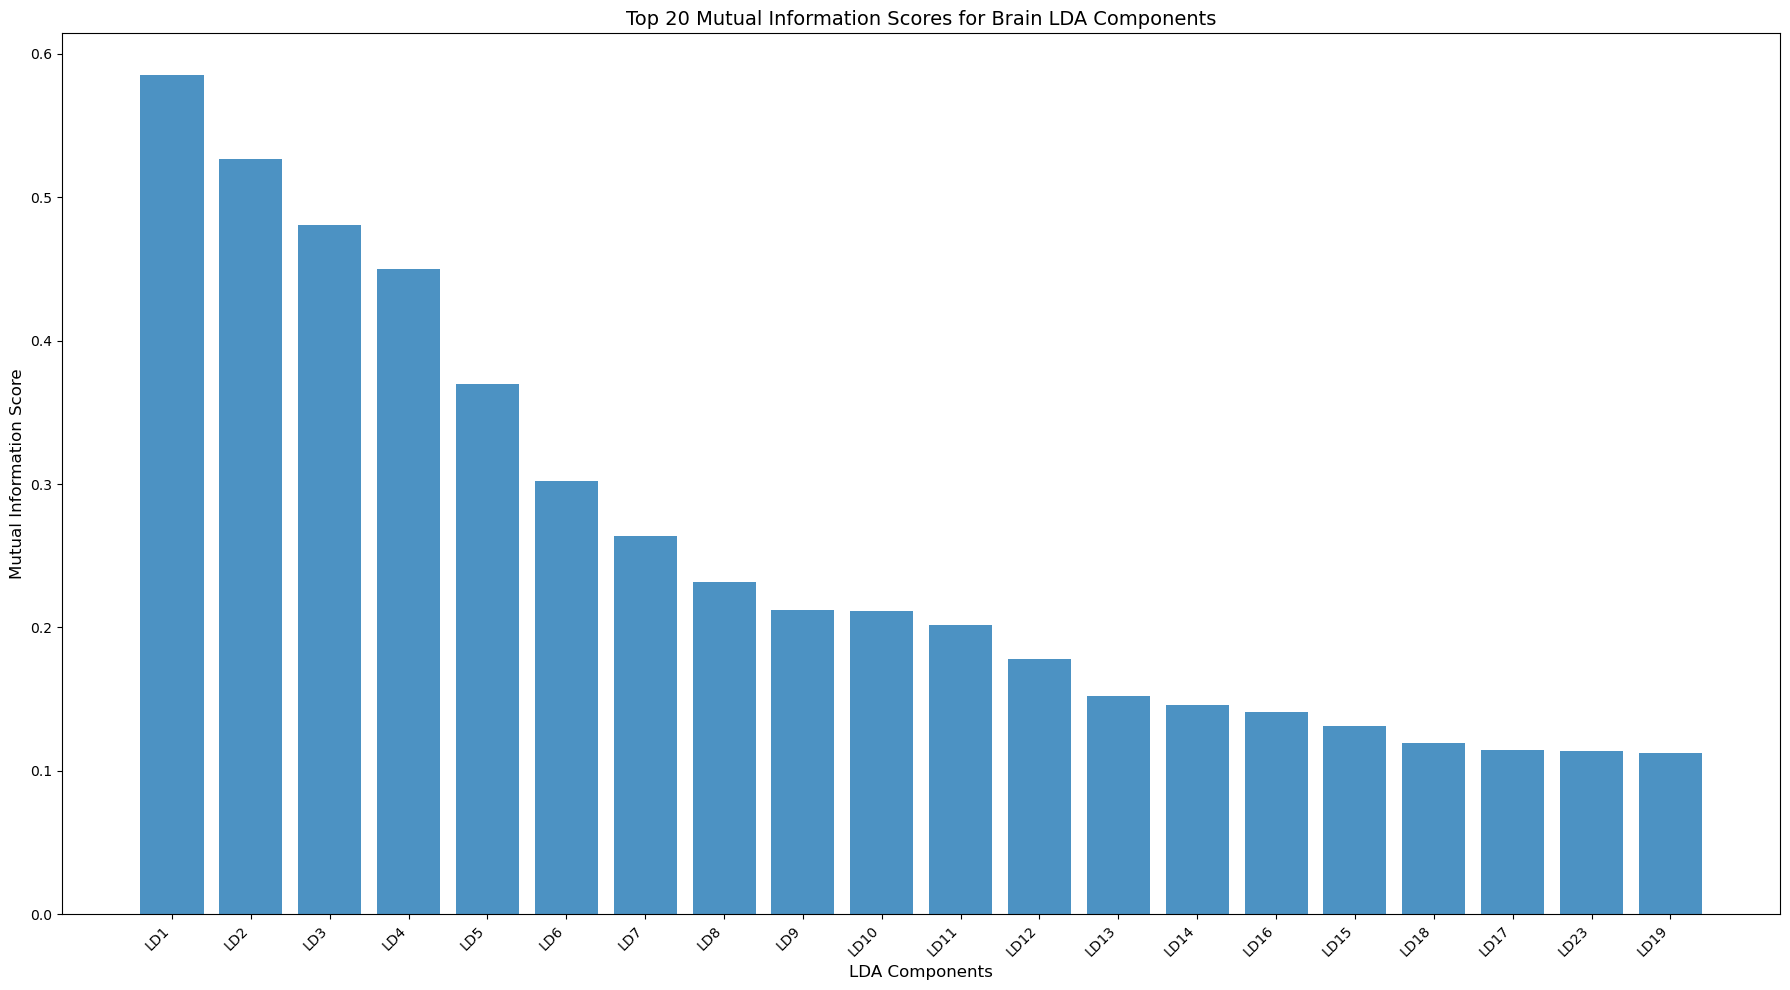

In [22]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Assuming mi_df is your DataFrame with 'Feature' and 'MI Score' columns
# Sort the DataFrame by 'MI Score' in descending order and select the top 20 features
mi_df = mi_df.sort_values(by='MI Score', ascending=False).head(20)

# # Define quartile colors
# colors = ['#36669c', '#41a0ae', '#3ec995', '#77f07f']  # Colors for each quartile

# Determine quartile ranges for the top 20 features
num_features = len(mi_df['Feature'])
quartile_size = num_features // 4  # Number of features per quartile

# Plot the data
plt.figure(figsize=(18, 10))
# plt.bar(mi_df['Feature'], mi_df['MI Score'], color=bar_colors, alpha=0.8)
plt.bar(mi_df['Feature'], mi_df['MI Score'], alpha=0.8)
# Add axis labels and title
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.title('Top 20 Mutual Information Scores for Brain LDA Components', fontsize=14)
plt.xlabel('LDA Components', fontsize=12)
plt.ylabel('Mutual Information Score', fontsize=12)

# # Add a legend to explain quartiles
# legend_labels = ['First Quartile (0-25%)', 'Second Quartile (26-50%)', 'Third Quartile (51-75%)', 'Fourth Quartile (76-100%)']
# legend_patches = [mpatches.Patch(color=colors[i], label=legend_labels[i]) for i in range(4)]
# plt.legend(handles=legend_patches, title="X-axis Quartiles", fontsize=10)

# Improve layout
plt.tight_layout()
plt.show()

In [23]:
# Threshold and selected components
threshold = np.percentile(mi_scores, 75)
selected_components = np.where(mi_scores > threshold)[0]
print(f"Selected LDA components: {selected_components}")

# Filter the PCA-transformed dataset using these indices
brain_selected_components_data = reduced_data[:, selected_components]
print(f"Filtered Data Shape: {brain_selected_components_data.shape}")

Selected LDA components: [  0   1   2   3   4   5   6   7   8   9  10  11  12  13  14  15  16  17
  18  19  20  21  22  23  24  25  26  27  28  29  30  31  32  33  34  35
  36  37  38  39  40  41  42  43  44  45  46  47  48  49  50  51  52  53
  54  55  56  57  58  59  60  61  62  63  64  65  66  67  68  69  70  71
  72  73  74  75  76  77  78  79  80  81  82  83  84  85  86  87  88  89
  90  91  92  93  94  95  96  97  98  99 100 101 102 103 104 105 106 107
 108 109 110 111 112 113 114 115 116 117 118 119 120 121 122 125 126 128
 129 130 132 133 134 135 137 138 139 141 143 144 149 155]
Filtered Data Shape: (16540, 140)


In [24]:
# Check the shape of the reduced dataset
print("Shape of Selected Features Data:", brain_selected_components_data.shape)

Shape of Selected Features Data: (16540, 140)


In [25]:
brain_selected_components_data = torch.from_numpy(brain_selected_components_data)

In [26]:
#Use 20 categories
index_seen = np.squeeze(np.where(label_seen < 21, True, False))
index_unseen = np.squeeze(np.where(label_unseen < 21, True, False))

brain_seen = brain_selected_components_data[index_seen, :]
# brain_seen = reduced_data[index_seen, :]
image_seen = image_seen[index_seen, :]
text_seen = text_seen[index_seen, :]
label_seen = label_seen[index_seen]
brain_unseen = brain_unseen[index_unseen, :]
image_unseen = image_unseen[index_unseen, :]
text_unseen = text_unseen[index_unseen, :]
label_unseen = label_unseen[index_unseen]

#The ThingsEEG-Text dataset is mainly designed and used for Zero-Shot type research work, because the independence of its training set and test set
#in categories is very suitable for this task. If it needs to be used for other types of tasks
#(such as general classification or cross-modal learning),
#the data may need to be repartitioned. Therefore, we repartition the dataset to make it better for our task
#Define the number of classes and the number of samples per class
num_classes = 20
samples_per_class = 10

import torch
#For each class, take the first 5 images as training and the last 5 images as testing
new_train_brain = []
new_train_image = []
new_train_text = []
new_train_label = []

new_test_brain = []
new_test_image = []
new_test_text = []
new_test_label = []

# Convert numpy arrays to PyTorch tensors before appending
for i in range(num_classes):
    start_idx = i * samples_per_class  # The starting index of the current class
    end_idx = start_idx + samples_per_class  # The end index of the current class

    # Get the data of the current class
    class_data_brain = torch.tensor(brain_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_brain.append(class_data_brain[:7])
    new_test_brain.append(class_data_brain[7:])

    class_data_image = torch.tensor(image_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_image.append(class_data_image[:7])
    new_test_image.append(class_data_image[7:])

    class_data_text = torch.tensor(text_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_text.append(class_data_text[:7])
    new_test_text.append(class_data_text[7:])

    class_data_label = torch.tensor(label_seen[start_idx:end_idx, :])  # Convert to tensor
    new_train_label.append(class_data_label[:7])
    new_test_label.append(class_data_label[7:])

# Stack the tensors
train_brain = torch.vstack(new_train_brain)
train_image = torch.vstack(new_train_image)
train_text = torch.vstack(new_train_text)
train_label = torch.vstack(new_train_label)
test_brain = torch.vstack(new_test_brain)
test_image = torch.vstack(new_test_image)
test_text = torch.vstack(new_test_text)
test_label = torch.vstack(new_test_label)

# Print shapes
print(train_brain.shape)
print(train_image.shape)
print(train_text.shape)
print(train_label.shape)
print(test_brain.shape)
print(test_image.shape)
print(test_text.shape)
print(test_label.shape)

torch.Size([140, 140])
torch.Size([140, 100])
torch.Size([140, 512])
torch.Size([140, 1])
torch.Size([60, 140])
torch.Size([60, 100])
torch.Size([60, 512])
torch.Size([60, 1])


/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_38602/3048466901.py:41: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_data_brain = torch.tensor(brain_seen[start_idx:end_idx, :])  # Convert to tensor
/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_38602/3048466901.py:45: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(sourceTensor).
  class_data_image = torch.tensor(image_seen[start_idx:end_idx, :])  # Convert to tensor
/var/folders/63/sts5pq893c76k079c87fr3s40000gn/T/ipykernel_38602/3048466901.py:49: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.clone().detach() or sourceTensor.clone().detach().requires_grad_(True), rather than torch.tensor(

In [27]:
train_brain

tensor([[ 1.3917,  2.5551, -0.4233,  ...,  0.1600, -0.4996, -1.0094],
        [-0.5841,  1.5764, -0.9648,  ...,  1.7847,  0.1603,  1.2787],
        [ 1.0168,  1.5954, -0.8530,  ...,  1.2673, -1.3516, -0.0581],
        ...,
        [-0.6181,  0.7264, -2.4069,  ..., -0.5041, -0.4534,  1.9274],
        [ 0.5974, -0.3647,  1.0978,  ...,  0.2692, -1.9628, -0.4074],
        [ 0.2036, -0.0904, -1.5346,  ...,  0.4256, -1.5691,  0.5797]],
       dtype=torch.float64)

In [28]:
train_label.shape

torch.Size([140, 1])

In [29]:
test_brain

tensor([[ 0.5038,  3.0961,  0.3815,  ..., -0.7619,  0.7999, -1.4165],
        [-0.4111,  1.3875, -0.7434,  ...,  1.0358,  0.5638,  0.9546],
        [-0.1505,  0.6129, -0.7030,  ..., -0.0463,  0.1208,  1.6470],
        ...,
        [-0.3058,  1.1943, -1.2923,  ...,  0.6669, -1.1406,  0.6435],
        [ 0.6546,  1.5184, -2.2669,  ...,  0.4881,  0.4884, -0.3674],
        [-1.1764, -0.6210, -1.8931,  ...,  0.2462, -1.5816, -0.1476]],
       dtype=torch.float64)

In [30]:
# train_label = train_label.squeeze()
# test_label = test_label.squeeze()

In [31]:
# Train a model using the reduced feature set
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Step 1: Train a Random Forest Classifier on the reduced training set
clf = RandomForestClassifier(n_estimators=49)
clf.fit(train_brain, train_label)

# Step 2: Make predictions on the test set
pred_brain = clf.predict(test_brain)

# Step 3: Evaluate the model
accuracy = accuracy_score(test_label, pred_brain)
print(f"Test Set Accuracy: {accuracy:.2f}")

Test Set Accuracy: 0.40


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/base.py:1473: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


In [41]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Initialize KNN model 9
knn = KNeighborsClassifier(n_neighbors=9)
knn.fit(train_brain, train_label)

pred_brain = knn.predict(test_brain)

accuracy = accuracy_score(test_label, pred_brain)
print(f"Test Set Accuracy: {accuracy:.2f}")

Test Set Accuracy: 0.67


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/neighbors/_classification.py:238: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


In [33]:
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

svc = SVC(kernel='poly', degree=8)
svc.fit(train_brain, train_label)

pred_brain = svc.predict(test_brain)

accuracy = accuracy_score(test_label, pred_brain)
print(f"Test Set Accuracy: {accuracy:.2f}")

Test Set Accuracy: 0.05


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [34]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report, accuracy_score

# 1. Initialize the SVM model
# You can experiment with different kernels: 'linear', 'rbf', 'poly', or 'sigmoid'
svm_model = SVC(kernel='rbf', C=1.0, gamma='scale', random_state=42)

# 2. Train the SVM model on the training data
svm_model.fit(train_brain, train_label)

# 3. Make predictions on the test data
pred_brain = svm_model.predict(test_brain)

# 4. Evaluate the model
print("Accuracy on Test Data:", accuracy_score(test_label, pred_brain))

Accuracy on Test Data: 0.8833333333333333


/Users/sami/anaconda3/lib/python3.11/site-packages/sklearn/utils/validation.py:1339: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


In [35]:
# train_label = train_label.ravel()

In [36]:
# Making out "own" model via taking source code from scikitlearn